# E-Commerce Sales Analysis Project

## Executive Summary

This project analyzes 10,000 e-commerce transactions to understand customer behavior, sales performance, 
product trends, payment preferences, and revenue drivers.

The objective is to transform raw transactional data into meaningful business insights using Python, 
Pandas, Matplotlib, and Seaborn. The analysis helps identify opportunities for increasing revenue, 
improving customer experience, and supporting data-driven decision making.


## Data Cleaning

The following data cleaning and preprocessing steps were performed:

- Checked dataset structure and dimensions.
- Verified data types using `df.info()`.
- Checked for duplicate records.
- Checked for missing values.
- Converted date columns to datetime format.
- Created a new `total_sale` feature.
- Validated categorical and numerical columns before analysis.

The dataset was then prepared for business analysis and visualization.

## Exploratory Data Analysis (EDA)

EDA was performed to understand patterns within the dataset.

Areas explored:

- Customer demographics
- Product categories
- Geographic performance
- Revenue generation
- Payment behavior
- Order status
- Monthly sales trends
- Top-performing products

The findings from EDA were later converted into business insights and recommendations.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [98]:
df= pd.read_csv(r'ecommerce_dataset_10000.csv')

In [99]:
df.head(5)

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     10000 non-null  object
 1   first_name      10000 non-null  object
 2   last_name       10000 non-null  object
 3   gender          10000 non-null  object
 4   age_group       10000 non-null  object
 5   signup_date     10000 non-null  object
 6   country         10000 non-null  object
 7   product_id      10000 non-null  object
 8   product_name    10000 non-null  object
 9   category        10000 non-null  object
 10  quantity        10000 non-null  int64 
 11  unit_price      10000 non-null  int64 
 12  order_id        10000 non-null  object
 13  order_date      10000 non-null  object
 14  order_status    10000 non-null  object
 15  payment_method  10000 non-null  object
 16  rating          10000 non-null  int64 
 17  review_text     10000 non-null  object
 18  review_

In [101]:
df.shape

(10000, 20)

In [131]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [103]:
df['rating'].astype(int)

0       2
1       2
2       5
3       2
4       1
       ..
9995    4
9996    1
9997    3
9998    2
9999    3
Name: rating, Length: 10000, dtype: int64

In [132]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [105]:
df['signup_date']=pd.to_datetime(df['signup_date'])

In [106]:
df['order_date']=pd.to_datetime(df['order_date'])

In [107]:
df['review_date']=pd.to_datetime(df['review_date'])

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     10000 non-null  object        
 1   first_name      10000 non-null  object        
 2   last_name       10000 non-null  object        
 3   gender          10000 non-null  object        
 4   age_group       10000 non-null  object        
 5   signup_date     10000 non-null  datetime64[ns]
 6   country         10000 non-null  object        
 7   product_id      10000 non-null  object        
 8   product_name    10000 non-null  object        
 9   category        10000 non-null  object        
 10  quantity        10000 non-null  int64         
 11  unit_price      10000 non-null  int64         
 12  order_id        10000 non-null  object        
 13  order_date      10000 non-null  datetime64[ns]
 14  order_status    10000 non-null  object        
 15  pay

In [109]:
df.describe()

,signup_date,quantity,unit_price,order_date,rating,review_date
count,10000,10000.000000,10000.000000,10000,10000.000000,10000
mean,2023-03-18 21:25:29.280000,3.000800,246.647200,2024-02-23 19:23:48.480000,2.993100,2024-02-22 02:04:42.240000
min,2020-08-24 00:00:00,1.000000,25.000000,2022-08-25 00:00:00,1.000000,2022-08-25 00:00:00
25%,2021-12-26 00:00:00,2.000000,80.000000,2023-05-25 00:00:00,2.000000,2023-05-22 00:00:00
50%,2023-03-25 12:00:00,3.000000,129.000000,2024-02-26 00:00:00,3.000000,2024-02-19 00:00:00
75%,2024-06-06 00:00:00,4.000000,229.000000,2024-11-22 00:00:00,4.000000,2024-11-26 00:00:00
max,2025-08-24 00:00:00,5.000000,999.000000,2025-08-24 00:00:00,5.000000,2025-08-24 00:00:00
std,NaN,1.416474,282.605391,NaN,1.410621,NaN


In [110]:
df['total_sale']=df['quantity']*df['unit_price']

In [111]:
df.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,...,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date,total_sale
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,...,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06,687
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,...,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05,236
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,...,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03,118
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14,1596
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,...,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18,110


In [113]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [114]:
df['review_text'].unique()

array(['good', 'average', 'very good', 'bad', 'very bad'], dtype=object)

In [115]:
df['payment_method'].unique()

array(['Credit Card', 'PayPal', 'Cash on Delivery'], dtype=object)

In [116]:
df['order_status'].unique()

array(['Pending', 'Delivered', 'Returned', 'Shipped', 'Cancelled'],
      dtype=object)

### KPI

In [119]:
total_order=df['order_id'].nunique()
print('Total Number of Orders:-',total_order)


total_revenue=df['total_sale'].sum()
print('Total Revenue:-',total_revenue)


Top_Country=df['country'].mode()[0]
print('Top country to order:-',Top_Country)


average_order = total_revenue/total_order
print('Average Order Value:-',average_order)


total_customer = df['customer_id'].nunique()
print('Total CUstomers :-',total_customer)


cancelled_order=(df['order_status'] == 'Cancelled').sum()
print('Total Cancelled Order:-',cancelled_order)

Total Number of Orders:- 10000
Total Revenue:- 7450763
Top country to order:- France
Average Order Value:- 745.0763
Total CUstomers :- 4327
Total Cancelled Order:- 1970


In [120]:
print('Most Payment Method uses:-',df['payment_method'].mode()[0])

print('Most Customer Belongs to :-',df['gender'].mode()[0],'gender')

Most Payment Method uses:- Cash on Delivery
Most Customer Belongs to :- Other gender


### Sales by Category

category
Electronics       4529986
Home & Kitchen    1069650
Apparel            597636
Toys               499894
Books              415797
Sports             337800
Name: total_sale, dtype: int64

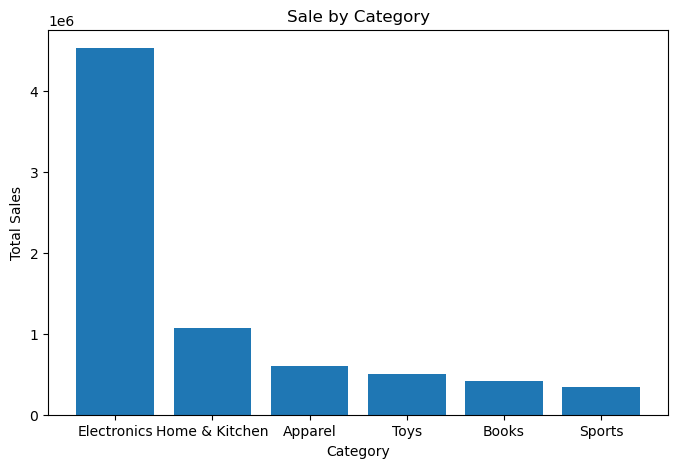

In [121]:
category_tsale=df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

index= category_tsale.index
value= category_tsale.values

plt.figure(figsize=(8, 5))
plt.bar(index,value)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Sale by Category")

category_tsale

In [122]:
df['customer_id'].value_counts().sort_values(ascending=False).head(5)

customer_id
CUST1244    9
CUST5023    8
CUST2133    7
CUST2192    7
CUST3967    7
Name: count, dtype: int64

### Sales by Country

Text(0.5, 1.0, 'Sales by Country')

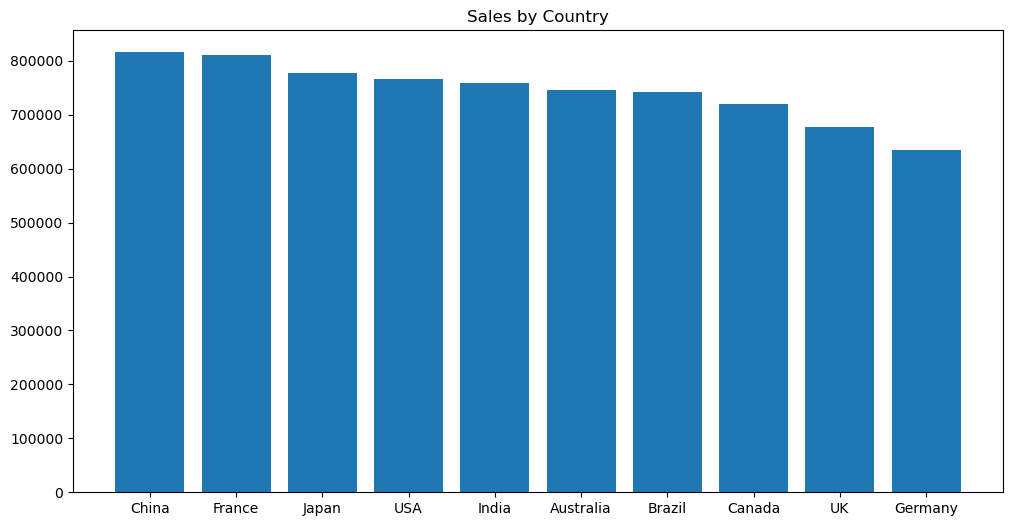

In [123]:
country_tsale=df.groupby('country')['total_sale'].sum().sort_values(ascending=False)

index1= country_tsale.index
value2= country_tsale.values

plt.figure(figsize=(12, 6))
plt.bar(index1,value2)
plt.title('Sales by Country')

### Revenue by Age Group

age_group
Adults       2551635
Teenagers    2511994
Senior       2387134
Name: total_sale, dtype: int64

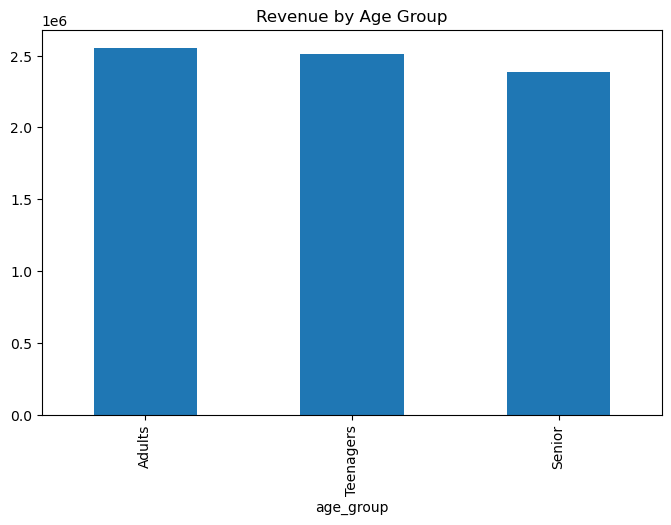

In [124]:
age_revenue= df.groupby('age_group')['total_sale'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
age_revenue.plot(kind='bar')
plt.title('Revenue by Age Group')

age_revenue

### Order Status Distribution

order_status
Shipped      2063
Delivered    2037
Cancelled    1970
Pending      1968
Returned     1962
Name: count, dtype: int64

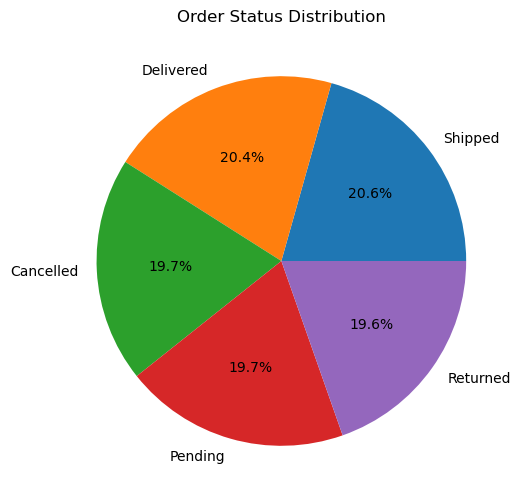

In [125]:
order= df['order_status'].value_counts()
plt.figure(figsize=(6, 6))
order.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Order Status Distribution')
order

### Payment Method Usage

payment_method
Cash on Delivery    3409
PayPal              3301
Credit Card         3290
Name: count, dtype: int64

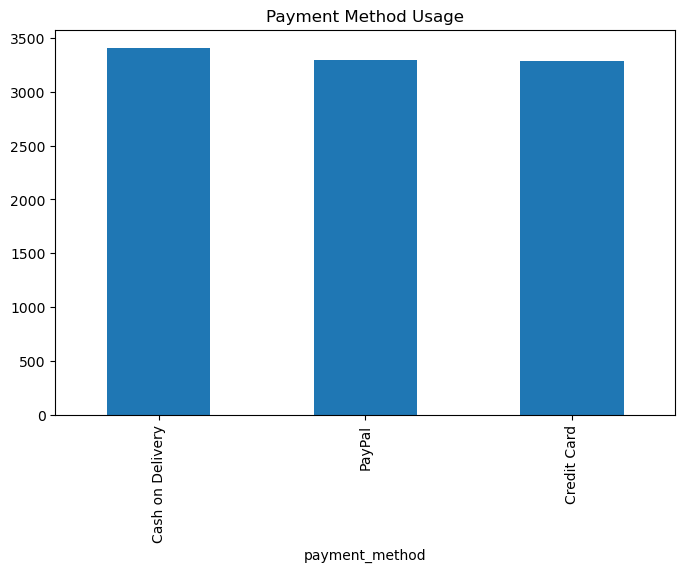

In [126]:
Payment= df['payment_method'].value_counts()
plt.figure(figsize=(8,5))
Payment.plot(kind='bar')
plt.title('Payment Method Usage')

Payment

### Monthly Trends

Order_Month
January      595249
February     558100
March        623648
April        659233
May          632774
June         645656
July         630619
August       645125
September    612033
October      633059
November     659498
December     555769
Name: total_sale, dtype: int64

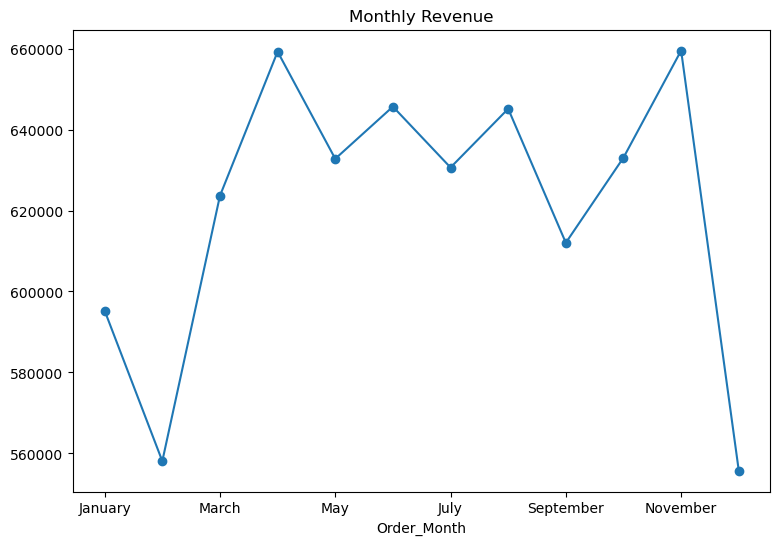

In [141]:
df['Order_Month'] = df['order_date'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
Month_revenue= df.groupby('Order_Month')['total_sale'].sum().reindex(month_order)
plt.figure(figsize=(9,6))
Month_revenue.plot(kind='line',marker='o')
plt.title('Monthly Revenue')

Month_revenue

### Top 5 country by Sale

product_name
iPhone 14             1881117
Samsung Galaxy S23    1780919
Dyson Vacuum           876204
Fitbit Versa 3         442886
Sony Headphones        425064
Name: total_sale, dtype: int64

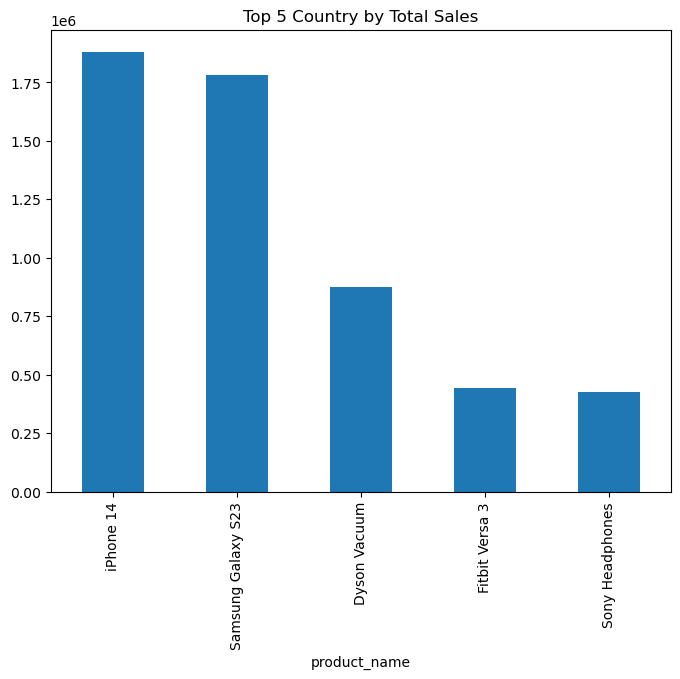

In [128]:
Top_5_products= df.groupby('product_name')['total_sale'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,6))
Top_5_products.plot(kind='bar')
plt.title('Top 5 Country by Total Sales')

Top_5_products

## Insights

### KEY_FINDINGS

• France emerged as the highest revenue-generating country.

• Electronics was the best-performing product category in terms of sales revenue.

• Adult customers represented the most profitable customer segment.

• Cash on Delivery was the dominant payment method, highlighting customer preference for payment flexibility.

• Nearly 20% of orders were either cancelled or returned, suggesting opportunities to improve customer experience and operational efficiency.

### RECOMMENDATIONS

1. Increase marketing efforts and personalized campaigns targeting adult customers, as they represent the highest-revenue customer segment.

2. Reduce cancellation and return rates by improving product quality checks, order accuracy, and delivery performance.

3. Maintain adequate inventory levels for Electronics products to prevent stockouts and maximize revenue opportunities.

4. Expand marketing and customer acquisition efforts in France and other high-performing regions to strengthen market presence and drive further growth.

5. Analyze the reasons behind cancelled and returned orders to identify operational inefficiencies and improve customer satisfaction.

## Conclusion

This analysis identified key revenue drivers, customer purchasing patterns, and product performance trends within the e-commerce business.

The results show that revenue is concentrated among specific products, categories, customer segments, and countries. By leveraging these insights, businesses can optimize marketing strategies, improve inventory management, reduce cancellations and returns, and enhance customer retention efforts.

Overall, this project demonstrates how data analytics can transform raw business data into actionable insights that support informed decision-making and business growth.

